--- Successfully loaded both CSV files. ---


--- Inspecting 'gender_MASTER_clean.csv' ---
Shape: (27496, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27496 entries, 0 to 27495
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   subreddit            27496 non-null  object 
 1   post_id              27496 non-null  object 
 2   post_created_utc     27496 non-null  float64
 3   post_title           27496 non-null  object 
 4   post_body            26080 non-null  object 
 5   post_score           27496 non-null  float64
 6   post_url             27496 non-null  object 
 7   comment_id           27496 non-null  object 
 8   comment_body         27496 non-null  object 
 9   comment_score        27496 non-null  float64
 10  comment_created_utc  27496 non-null  float64
dtypes: float64(4), object(7)
memory usage: 2.3+ MB
None

Head:
     subreddit  post_id  post_created_utc  \
0  transgender  12jz4v

C:\Users\chauh\AppData\Local\Temp\ipykernel_20772\1633281586.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_15_subreddits.index, x=top_15_subreddits.values, palette="viridis")



Generated 'top_15_subreddits.png'

Analyzing Post/Comment Time...
Earliest Entry: 2011-01-09 02:58:28
Latest Entry: 2025-10-26 14:12:34
Generated 'time_distribution.png'

Rows with missing 'comment_body': 0 (0.00%)
Rows with missing 'post_body': 8936 (8.86%)

Total rows with NO text in 'comment_body' OR 'post_body': 0
Dropped 0 rows with no text. New shape: (100875, 14)

--- Phase 1 Complete. ---
Saved 'MASTER_combined_and_cleaned.csv' for our next phase.


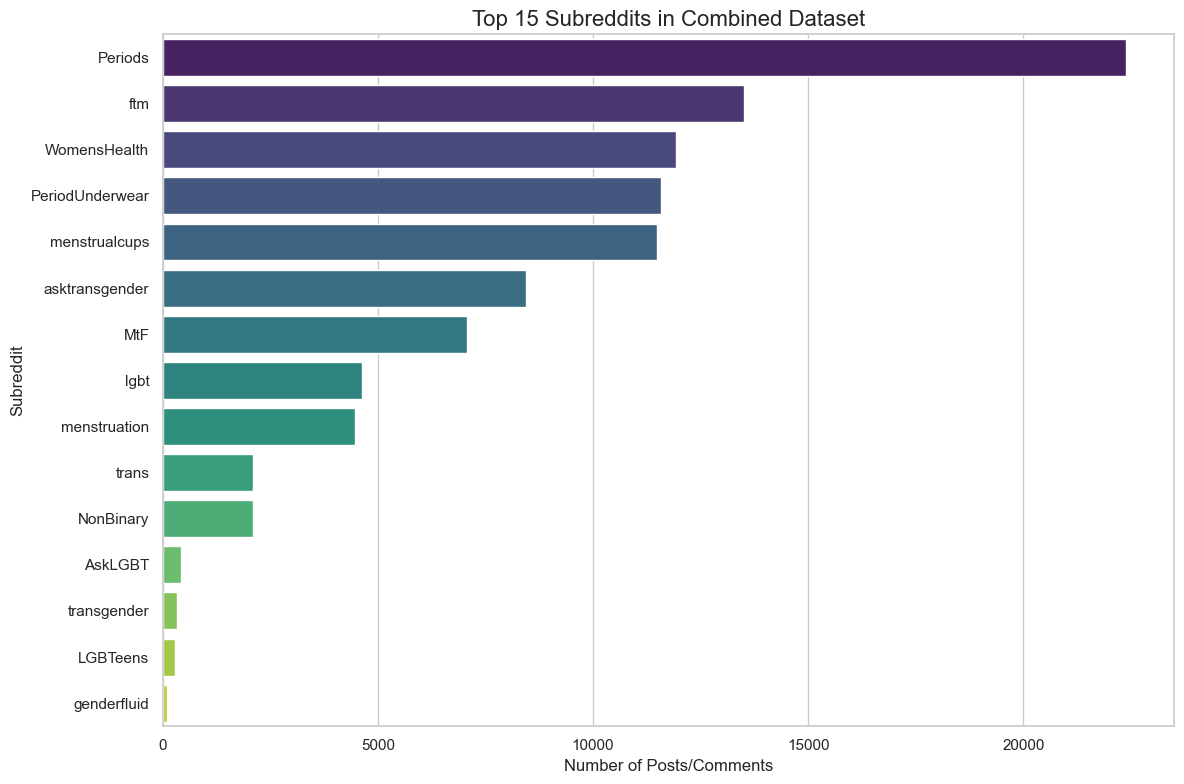

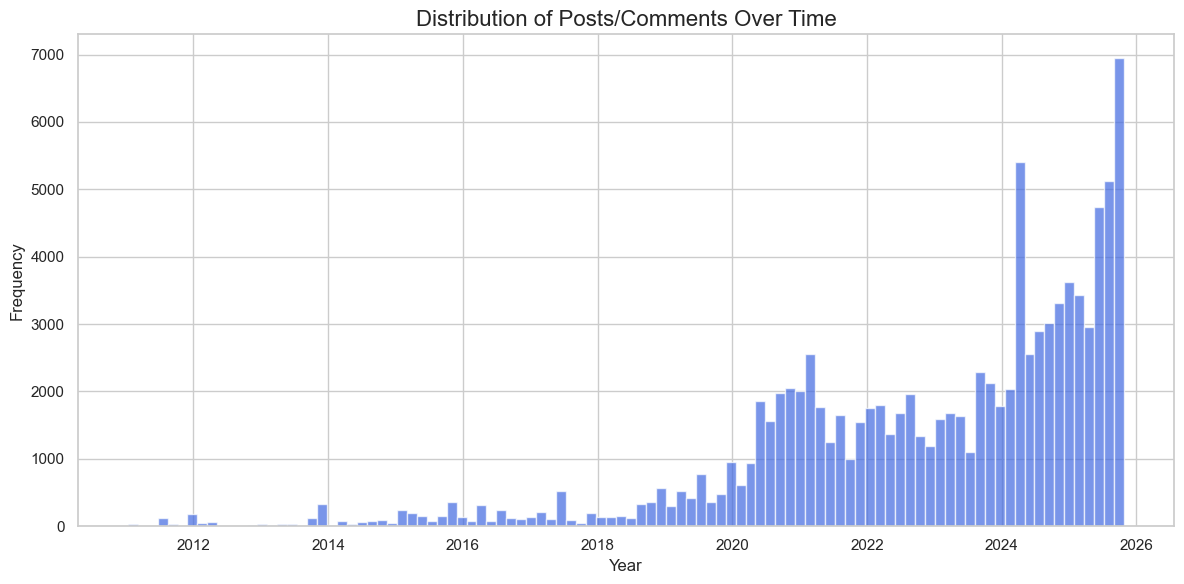

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better visuals
sns.set_theme(style="whitegrid")

# Load the datasets
try:
    df_gender = pd.read_csv("gender_MASTER_clean.csv")
    df_products = pd.read_csv("products_MASTER_clean.csv")
    print("--- Successfully loaded both CSV files. ---")
    print("\n")

    # --- 1. Initial Inspection: gender_MASTER_clean.csv ---
    print("--- Inspecting 'gender_MASTER_clean.csv' ---")
    print(f"Shape: {df_gender.shape}")
    print(df_gender.info())
    print("\nHead:")
    print(df_gender.head())
    print("\n")

    # --- 2. Initial Inspection: products_MASTER_clean.csv ---
    print("--- Inspecting 'products_MASTER_clean.csv' ---")
    print(f"Shape: {df_products.shape}")
    print(df_products.info())
    print("\nHead:")
    print(df_products.head())
    print("\n")

    # --- 3. Prepare for Merge ---
    # Add a 'source' column to track origin
    df_gender['source'] = 'gender'
    df_products['source'] = 'product'
    
    # Check for column consistency
    gender_cols = set(df_gender.columns)
    product_cols = set(df_products.columns)
    
    if gender_cols != product_cols:
        print("Warning: Column names or order do not match perfectly.")
        print(f"Gender columns not in Product: {gender_cols - product_cols}")
        print(f"Product columns not in Gender: {product_cols - gender_cols}")
        # For this project, we'll proceed by combining on common columns
        # but this is a critical observation.
    
    # Combine the two dataframes
    master_df = pd.concat([df_gender, df_products], ignore_index=True)
    print("--- Combined DataFrames into 'master_df' ---")
    print(f"Master DF Shape: {master_df.shape}")
    print("\n")

    # --- 4. Post-Merge EDA ---
    print("--- Post-Merge Analysis ---")
    print(master_df.info())
    
    # Check for missing values
    print("\nMissing Values:")
    print(master_df.isnull().sum())

    # --- 5. Key Column Analysis ---
    
    # Analyze the 'source' column
    print("\nData Source Distribution:")
    print(master_df['source'].value_counts(normalize=True))

    # Analyze the 'subreddit' column
    print("\nTop 15 Subreddits (Overall):")
    print(master_df['subreddit'].value_counts().head(15))
    
    # Save the top subreddits for plotting
    top_15_subreddits = master_df['subreddit'].value_counts().head(15)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(y=top_15_subreddits.index, x=top_15_subreddits.values, palette="viridis")
    plt.title('Top 15 Subreddits in Combined Dataset', fontsize=16)
    plt.xlabel('Number of Posts/Comments', fontsize=12)
    plt.ylabel('Subreddit', fontsize=12)
    plt.tight_layout()
    plt.savefig('top_15_subreddits.png')
    print("\nGenerated 'top_15_subreddits.png'")

    # --- 6. Temporal Analysis (Time) ---
    print("\nAnalyzing Post/Comment Time...")
    # Convert UTC timestamps to datetime objects
    # We'll use 'comment_created_utc' as the primary time, as most rows are comments
    # Fallback to 'post_created_utc' if comment time is missing
    master_df['datetime'] = pd.to_datetime(master_df['comment_created_utc'].fillna(master_df['post_created_utc']), unit='s')

    print(f"Earliest Entry: {master_df['datetime'].min()}")
    print(f"Latest Entry: {master_df['datetime'].max()}")
    
    # Plot time distribution
    plt.figure(figsize=(12, 6))
    master_df['datetime'].hist(bins=100, color='royalblue', alpha=0.7)
    plt.title('Distribution of Posts/Comments Over Time', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.tight_layout()
    plt.savefig('time_distribution.png')
    print("Generated 'time_distribution.png'")

    # --- 7. Primary Text Column Analysis ---
    # Our analysis will focus on 'comment_body'. Let's see how many are missing.
    comment_missing = master_df['comment_body'].isnull().sum()
    post_body_missing = master_df['post_body'].isnull().sum()
    print(f"\nRows with missing 'comment_body': {comment_missing} ({(comment_missing/len(master_df)*100):.2f}%)")
    print(f"Rows with missing 'post_body': {post_body_missing} ({(post_body_missing/len(master_df)*100):.2f}%)")
    
    # Let's create our primary 'text_to_analyze' column
    # We will prioritize the comment, as it's the direct response.
    # If the comment is null, we'll use the post_body.
    # If both are null, it will be NaN.
    master_df['text_to_analyze'] = master_df['comment_body'].fillna(master_df['post_body'])
    
    text_missing = master_df['text_to_analyze'].isnull().sum()
    print(f"\nTotal rows with NO text in 'comment_body' OR 'post_body': {text_missing}")
    
    # We must drop these rows as they are unusable for text analysis
    original_count = len(master_df)
    master_df.dropna(subset=['text_to_analyze'], inplace=True)
    new_count = len(master_df)
    print(f"Dropped {original_count - new_count} rows with no text. New shape: {master_df.shape}")
    
    # Save the cleaned, merged DataFrame to a new CSV for the next steps
    master_df.to_csv('MASTER_combined_and_cleaned.csv', index=False)
    print("\n--- Phase 1 Complete. ---")
    print("Saved 'MASTER_combined_and_cleaned.csv' for our next phase.")

except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure both CSV files are in the correct directory.")
except Exception as e:
    print(f"An error occurred: {e}")